In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/EyeDiseaseProject"

!mkdir -p $PROJECT_DIR

print("Project folder created:", PROJECT_DIR)

Project folder created: /content/drive/MyDrive/EyeDiseaseProject


In [4]:
%cd /content

!git clone https://github.com/uzumstanley/Eye-Diseases-Detection.git

%cd Eye-Diseases-Detection

/content
Cloning into 'Eye-Diseases-Detection'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 48 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 3.71 MiB | 9.98 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/Eye-Diseases-Detection


In [5]:
!pip install tensorflow keras numpy matplotlib seaborn scikit-learn pandas pillow opencv-python gradio

In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"navin060","key":"17dbc9836b9b33fd59ffaf43c419fdf5"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:04<00:00, 165MB/s]



In [9]:
!unzip eye-diseases-classification.zip -d dataset/

Archive:  eye-diseases-classification.zip
  inflating: dataset/dataset/cataract/0_left.jpg  
  inflating: dataset/dataset/cataract/103_left.jpg  
  inflating: dataset/dataset/cataract/1062_right.jpg  
  inflating: dataset/dataset/cataract/1083_left.jpg  
  inflating: dataset/dataset/cataract/1084_right.jpg  
  inflating: dataset/dataset/cataract/1102_left.jpg  
  inflating: dataset/dataset/cataract/1102_right.jpg  
  inflating: dataset/dataset/cataract/1115_left.jpg  
  inflating: dataset/dataset/cataract/1126_right.jpg  
  inflating: dataset/dataset/cataract/112_right.jpg  
  inflating: dataset/dataset/cataract/1144_left.jpg  
  inflating: dataset/dataset/cataract/1144_right.jpg  
  inflating: dataset/dataset/cataract/1164_left.jpg  
  inflating: dataset/dataset/cataract/1167_right.jpg  
  inflating: dataset/dataset/cataract/119_left.jpg  
  inflating: dataset/dataset/cataract/1285_left.jpg  
  inflating: dataset/dataset/cataract/1415_left.jpg  
  inflating: dataset/dataset/cataract/1

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [11]:
DATA_DIR = 'dataset/dataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 4

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Found 3376 images belonging to 4 classes.
Found 841 images belonging to 4 classes.
Classes: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


In [13]:
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,419,396 (77.89 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        f'{PROJECT_DIR}/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [16]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.3978 - loss: 1.3020
Epoch 1: val_accuracy improved from None to 0.54935, saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 109s 881ms/step - accuracy: 0.4671 - loss: 1.1701 - val_accuracy: 0.5493 - val_loss: 1.0099
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.5954 - loss: 0.9271
Epoch 2: val_accuracy improved from 0.54935 to 0.58977, saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 764ms/step - accuracy: 0.6155 - loss: 0.9094 - val_accuracy: 0.5898 - val_loss: 0.9209
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.6532 - loss: 0.8351
Epoch 3: val_accuracy improved from 0.58977 to 0.62782, saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 84s 787ms/step - accuracy: 0.6511 - loss: 0.8271 - val_accuracy: 0.6278 - val_loss: 0.8602
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.6572 - loss: 0.8163
Epoch 4: val_accuracy improved from 0.62782 to 0.65993, saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 84s 792ms/step - accuracy: 0.6694 - loss: 0.8025 - val_accuracy: 0.6599 - val_loss: 0.8281
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.6745 - loss: 0.7672
Epoch 5: val_accuracy did not improve from 0.65993
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 764ms/step - accuracy: 0.6783 - loss: 0.7684 - val_accuracy: 0.5446 - val_loss: 1.0345
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.6636 - loss: 0.7889
Epoch 6: val_accuracy did not improve from 0.65993
106/106 ━━━━━━━━━━━━━━━━━━━━ 80s 753ms/step - accuracy: 0.6774 - loss: 0.7643 - val_accuracy: 0.6445 - val_loss: 0.8298
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.6976 - loss: 0.7387
Epoch 7: val_accuracy improved from 0.65993 to 0.67539, saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 84s 796ms/step - accuracy: 0.7032 - loss: 0.7283 - val_accuracy: 0.6754 - val_loss: 0.8006
Epoch 8/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.7094 - loss: 0.6982
Epoch 8: val_accuracy did not improve from 0.67539
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 773ms/step - accuracy: 0.7082 - loss: 0.7004 - val_accuracy: 0.6397 - val_loss: 0.8121
Epoch 9/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.7061 - loss: 0.7026
Epoch 9: val_accuracy did not improve from 0.67539
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 765ms/step - accuracy: 0.7142 - loss: 0.7044 - val_accuracy: 0.6278 - val_loss: 0.8360
Epoch 10/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.7219 - loss: 0.6694
Epoch 10: val_accuracy did not improve from 0.67539
106/106 ━━━━━━━━━━━━━━━━━━━━ 79s 746ms/step - accuracy: 0.7233 - loss: 0.6790 - val_accuracy: 0.6683 - val_loss: 0.7584
Epoch 11/30


Epoch 11: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 765ms/step - accuracy: 0.7233 - loss: 0.6815 - val_accuracy: 0.6873 - val_loss: 0.7559
Epoch 12/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7369 - loss: 0.6542
Epoch 12: val_accuracy did not improve from 0.68728
106/106 ━━━━━━━━━━━━━━━━━━━━ 79s 743ms/step - accuracy: 0.7319 - loss: 0.6551 - val_accuracy: 0.6659 - val_loss: 0.7674
Epoch 13/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.7387 - loss: 0.6568
Epoch 13: val_accuracy did not improve from 0.68728
106/106 ━━━━━━━━━━━━━━━━━━━━ 82s 740ms/step - accuracy: 0.7331 - loss: 0.6653 - val_accuracy: 0.6790 - val_loss: 0.7806
Epoch 14/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.7264 - loss: 0.6842
Epoch 14: val_accuracy did not improve from 0.68728
106/106 ━━━━━━━━━━━━━━━━━━━━ 80s 755ms/step - accuracy: 0.7257 - loss: 0.6845 - val_accuracy: 0.6373 - val_loss: 0.8225
Epoch 


Epoch 15: finished saving model to /content/drive/MyDrive/EyeDiseaseProject/best_model.h5
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 763ms/step - accuracy: 0.7305 - loss: 0.6563 - val_accuracy: 0.7015 - val_loss: 0.7276
Epoch 16/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.7204 - loss: 0.6681
Epoch 16: val_accuracy did not improve from 0.70155
106/106 ━━━━━━━━━━━━━━━━━━━━ 81s 748ms/step - accuracy: 0.7219 - loss: 0.6641 - val_accuracy: 0.6718 - val_loss: 0.7942
Epoch 17/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.7288 - loss: 0.6727
Epoch 17: val_accuracy did not improve from 0.70155
106/106 ━━━━━━━━━━━━━━━━━━━━ 80s 753ms/step - accuracy: 0.7340 - loss: 0.6652 - val_accuracy: 0.6659 - val_loss: 0.7573
Epoch 18/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.7285 - loss: 0.6663
Epoch 18: val_accuracy did not improve from 0.70155
106/106 ━━━━━━━━━━━━━━━━━━━━ 78s 738ms/step - accuracy: 0.7251 - loss: 0.6792 - val_accuracy: 0.6706 - val_loss: 0.7800
Epoch 

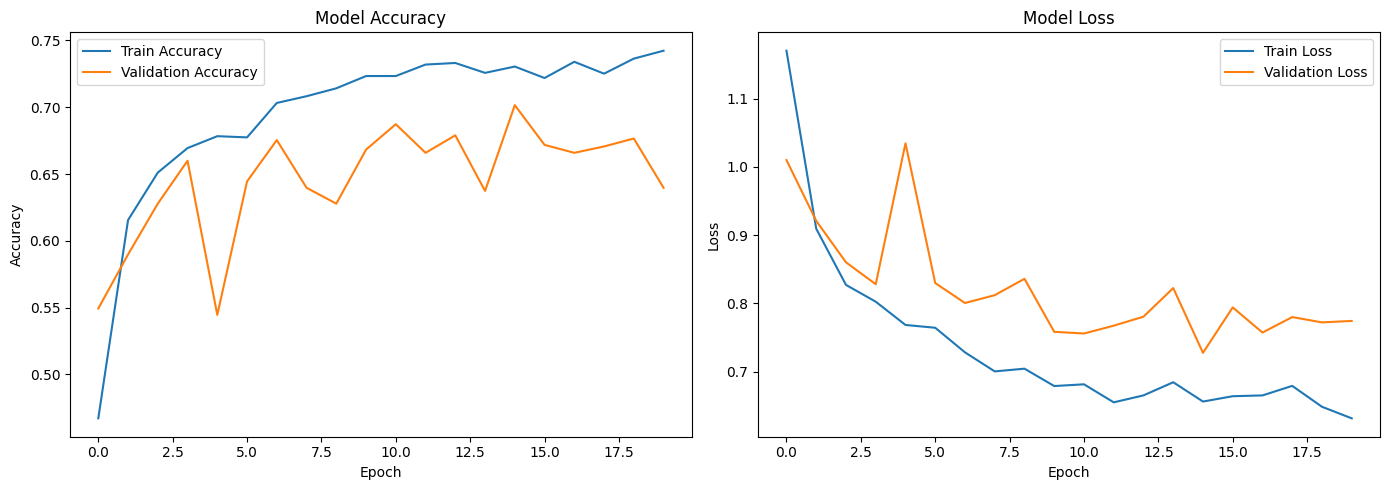

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()

# SAVE TO DRIVE
plt.savefig(f'{PROJECT_DIR}/accuracy_loss_plot.png')

plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 505ms/step


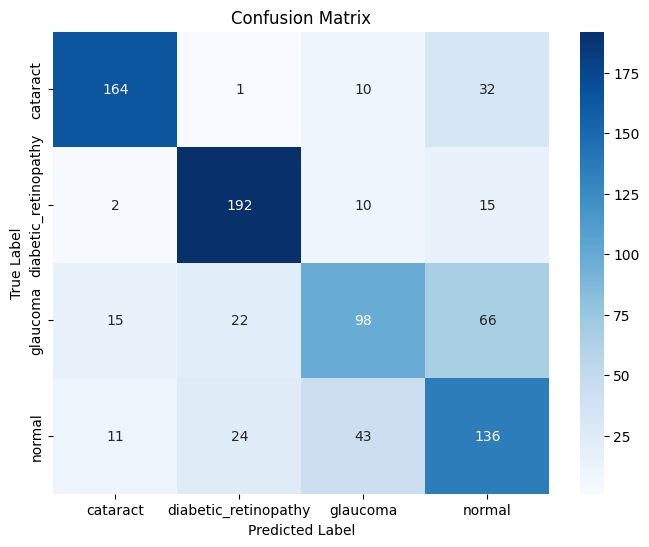

                      precision    recall  f1-score   support

            cataract       0.85      0.79      0.82       207
diabetic_retinopathy       0.80      0.88      0.84       219
            glaucoma       0.61      0.49      0.54       201
              normal       0.55      0.64      0.59       214

            accuracy                           0.70       841
           macro avg       0.70      0.70      0.70       841
        weighted avg       0.70      0.70      0.70       841



In [18]:
val_gen.reset()

# Predictions
y_pred_probs = model.predict(val_gen)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_gen.classes

# Class names
class_names = list(val_gen.class_indices.keys())

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# SAVE TO DRIVE
plt.savefig(f'{PROJECT_DIR}/confusion_matrix.png')

plt.show()

# CLASSIFICATION REPORT
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [19]:
from tensorflow.keras.models import load_model

model = load_model(f'{PROJECT_DIR}/best_model.h5')

print("Model loaded successfully")

Model loaded successfully


In [20]:
from tensorflow.keras.preprocessing import image

# Class labels
class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

def predict_eye_disease(img):

    # Resize image
    img = img.resize((224, 224))

    # Convert to array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)[0]

    # Create result dictionary
    results = {
        class_names[i]: float(prediction[i])
        for i in range(len(class_names))
    }

    return results

In [21]:
!pip install gradio

In [22]:
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

# Load saved model from Drive
model = load_model(f'{PROJECT_DIR}/best_model.h5')

# Automatically get class names
CLASS_NAMES = list(train_gen.class_indices.keys())

def predict_disease(img):

    # Resize image
    img_resized = img.resize((224, 224))

    # Convert image to array
    img_array = keras_image.img_to_array(img_resized) / 255.0

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array)[0]

    # Convert predictions to dictionary
    result = {
        CLASS_NAMES[i]: float(predictions[i])
        for i in range(len(CLASS_NAMES))
    }

    return result

# Create Gradio Interface
demo = gr.Interface(
    fn=predict_disease,

    inputs=gr.Image(
        type="pil",
        label="Upload Retinal Image"
    ),

    outputs=gr.Label(
        num_top_classes=4,
        label="Prediction"
    ),

    title="👁️ Eye Disease Detector",

    description="""
    Upload a retinal fundus image to detect:
    - Cataract
    - Diabetic Retinopathy
    - Glaucoma
    - Normal
    """,

    theme="soft"
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77dc54ec57267dc400.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
!ls "/content/drive/MyDrive/EyeDiseaseProject"

accuracy_loss_plot.png	best_model.h5  confusion_matrix.png


In [24]:
from google.colab import files

files.download(f'{PROJECT_DIR}/best_model.h5')
files.download(f'{PROJECT_DIR}/accuracy_loss_plot.png')
files.download(f'{PROJECT_DIR}/confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>